In [1]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

from visualize import plotColsOnMap
from format import removeEmptyRows, removeRed, objToNum, filterDepth, roundCoord, setND

# Tang depth integrated visualizations
This is meant to replicate the visualization done in the paper and see why the differences might occur.

In [2]:
keepers = ['LATITUDE', 'LONGITUDE', 'DEPTH (m)','Trichodesmium nifH Gene (x106 copies m-2)', 'Total UCYN-A nifH Gene (x106 copies m-2)','UCYN-B nifH Gene (x106 copies m-2)',"UCYN-A nifH Gene (x106 copies m-2)"]

In [3]:
tang_nifh = pd.read_csv("../csv/Tang_GeophysicalResLett_2019_Data_depth_int.csv")
print(tang_nifh.info())
tang_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 42 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    21 non-null     object 
 1   METHODS:                  Sampling/Analysis                     263 non-null    object 
 2   DATE (yyyy-mm-dd)                                               263 non-null    object 
 3   LATITUDE                                                        263 non-null    float64
 4   LONGITUDE                                                       263 non-null    float64
 5   Integral DEPTH (m)                                              263 non-null    float64
 6   Trichodesmium nifH Gene (x106 copies m-2)                       223 non-null    object 
 7   Trichodesmium Biomass Conversion factor (mg C/106 nif

,SOURCE: Data,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,Integral DEPTH (m),Trichodesmium nifH Gene (x106 copies m-2),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-2),UCYN-A1 nifH Gene (x106 copies m-2),...,CIII nifH Gene (x106 copies/m3),Total Diazotrophic Biomass (mg C m-2),Surface Temperature (˚C),Surface Salinity (PSU),Surface Nitrate (µM),Surface Phosphate (µM),N:P ratio,Surface Fe (nM),Chlorophyll (mg m-2),Notes
0,"Takuhei Shiozaki et al., 2014. Continetal Shel...",qPCR,2010 May,21.5,122.0,200.0,12000.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.02,0.03,NaN,NaN,NaN,NaN
1,NaN,qPCR,2010 May,21.5,122.5,200.0,16000.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.01,0.08,NaN,NaN,NaN,NaN
2,data shown in table 3,qPCR,2010 May,21.0,120.0,200.0,2100.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.01,0.03,NaN,NaN,NaN,NaN
3,NaN,qPCR,2010 May,21.0,119.5,200.0,1500.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.02,0.03,NaN,NaN,NaN,NaN
4,NaN,qPCR,2010 May,21.0,118.0,200.0,12000.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.01,0.04,NaN,NaN,NaN,NaN


In [4]:
tang_cols = ['Trichodesmium nifH Gene (x106 copies m-2)','UCYN-A nifH Gene (x106 copies m-2)','UCYN-B nifH Gene (x106 copies m-2)']

setND(tang_nifh, tang_cols)
#first step
objToNum(tang_nifh)
#tang_nifh.fillna(0, inplace=True)

#second step
tang_nifh_df = tang_nifh
#tang_nifh_df = removeEmptyRows(tang_cols,tang_nifh_df)

#check that nothign is lost
print(len(tang_nifh_df))

263


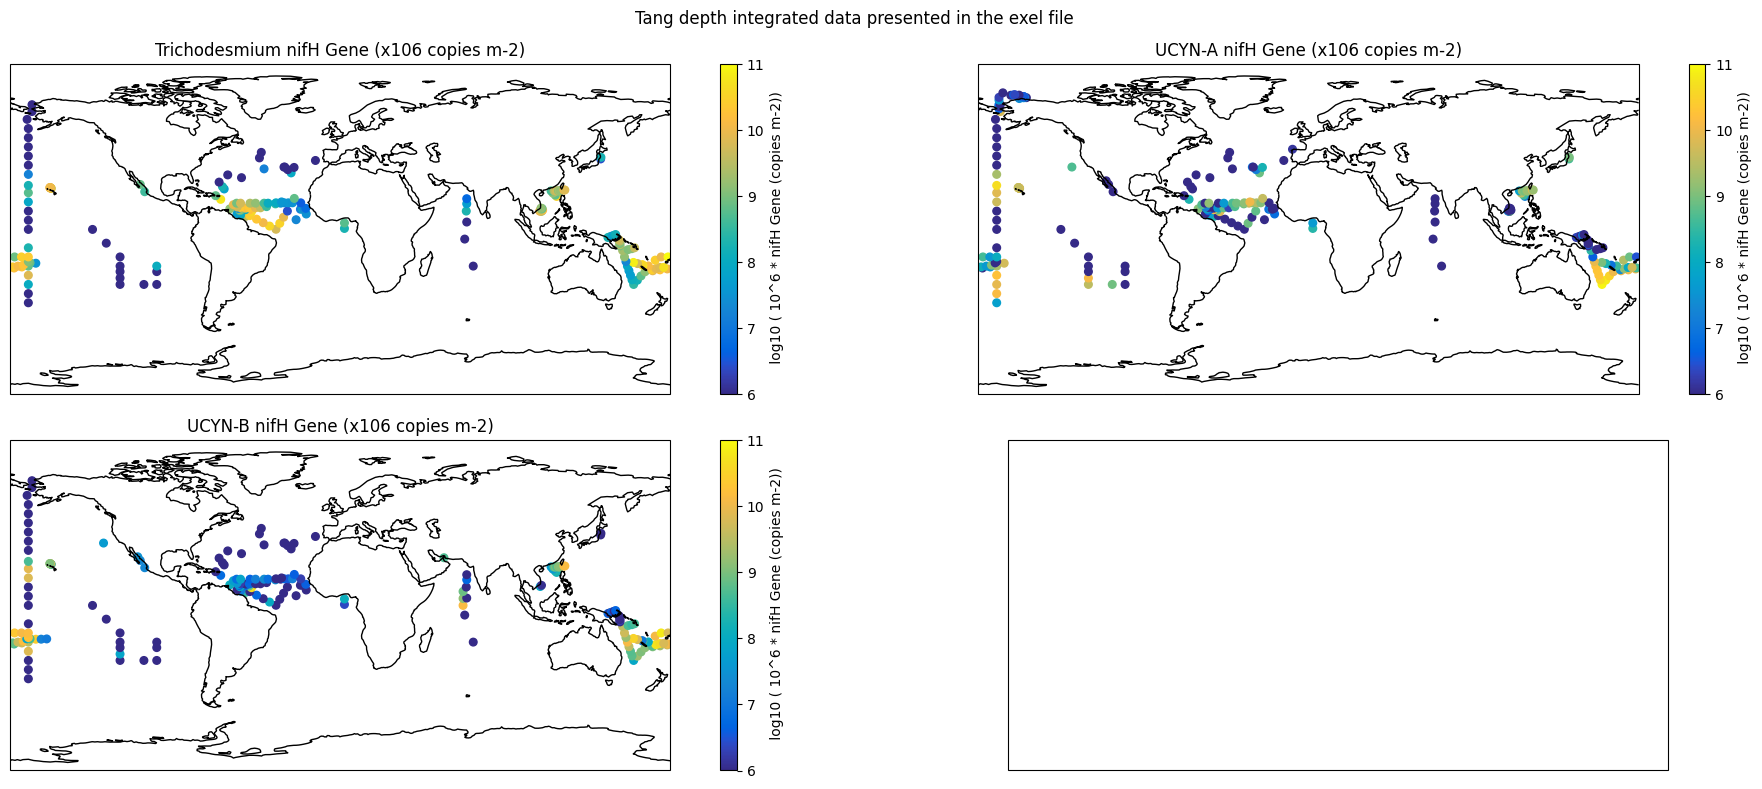

In [6]:
from parula_diy import parula_map

plotColsOnMap(
    tang_cols,tang_nifh_df,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label=" log10 ( 10^6 * nifH Gene (copies m-2))",
    title="Tang depth integrated data presented in the exel file",
    s=30
    )